# nb45 extension: Compton-Y$^2$ ratio to fiducial for all feedback variants, all redshifts

Extension of `45_compton_y2_ratio_fgas2sigma_Mz.ipynb`.  Now that every L1_m9 feedback-variant
halo catalogue has full Compton-Y columns, we can form the shot-noise / 1-halo sum
$S(M,z)=\sum_{i\in\mathrm{bin}} Y_i^2$ per $(M_{500c}, z)$ bin for **all** nine FLAMINGO
feedback prescriptions, and plot the ratio $R=S_{\rm variant}/S_{\rm fiducial}$ versus halo
mass in separate redshift panels (layout inspired by nb40).

Two apertures are shown:
* $Y_{500c}$ (within $R_{500c}$)
* $Y_{5R500c}$ (within $5R_{500c}$, Planck-style total flux)


In [1]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "figure.dpi": 100,
    "savefig.dpi": 300,
})

CAT_DIR = Path("/rds/rds-lxu/flamingo/L1_m9/catalogues")
FIG_DIR = Path("/scratch/scratch-lxu/flamingo_repo/figures/nb45_compton_y2_ratio_all_variants_Mz")
FIG_DIR.mkdir(parents=True, exist_ok=True)

VARIANTS = [
    "L1_m9",
    "fgas+2sigma",
    "fgas-2sigma",
    "fgas-4sigma",
    "fgas-8sigma",
    "Mstar-1sigma",
    "Mstar-1sigma_fgas-4sigma",
    "Jet",
    "Jet_fgas-4sigma",
]

LABELS = {
    "L1_m9": "fiducial (L1_m9)",
    "fgas+2sigma": "fgas +2$\\sigma$",
    "fgas-2sigma": "fgas $-$2$\\sigma$",
    "fgas-4sigma": "fgas $-$4$\\sigma$",
    "fgas-8sigma": "fgas $-$8$\\sigma$",
    "Mstar-1sigma": "M$_*$ $-$1$\\sigma$",
    "Mstar-1sigma_fgas-4sigma": "M$_*$ $-$1$\\sigma$, fgas $-$4$\\sigma$",
    "Jet": "Jet",
    "Jet_fgas-4sigma": "Jet + fgas $-$4$\\sigma$",
}

VARIANT_COLORS = dict(zip(VARIANTS, plt.cm.tab10(np.linspace(0, 0.95, len(VARIANTS)))))

RADII = ["Y_500c_Mpc2", "Y_5R500c_Mpc2"]
RADIUS_LABELS = {
    "Y_500c_Mpc2": r"$Y_{500c}$ (within $R_{500c}$)",
    "Y_5R500c_Mpc2": r"$Y_{5R500c}$ (within $5R_{500c}$)",
}


In [2]:
# --- Binning ---
M_EDGES = np.logspace(13.0, 15.2, 13)          # 12 mass bins, 1e13 .. ~1.6e15 Msun
Z_EDGES = np.array([0.0, 0.375, 0.75, 1.125, 1.5, 1.875, 2.25, 2.625, 3.0])  # 8 z bins
M_CEN = np.sqrt(M_EDGES[:-1] * M_EDGES[1:])
Z_CEN = 0.5 * (Z_EDGES[:-1] + Z_EDGES[1:])
MIN_COUNT = 10

print(f"Mass bins: {len(M_CEN)} edges {M_EDGES[0]:.2e} .. {M_EDGES[-1]:.2e}")
print(f"Redshift bins: {len(Z_CEN)}")
print(f"Minimum count per bin for ratio: {MIN_COUNT}")


Mass bins: 12 edges 1.00e+13 .. 1.58e+15
Redshift bins: 8
Minimum count per bin for ratio: 10


In [3]:
# --- Stream each catalogue and compute sum(Y^2) and counts per (M, z) bin ---

def sumsq_counts(path, ycol, m_edges, z_edges):
    s = np.zeros((len(m_edges) - 1, len(z_edges) - 1), dtype=np.float64)
    c = np.zeros((len(m_edges) - 1, len(z_edges) - 1), dtype=np.float64)
    t0 = time.time()
    for chunk in pd.read_csv(
        path,
        comment="#",
        usecols=["z", "M_500c_Msun", ycol],
        dtype={"z": np.float64, "M_500c_Msun": np.float64, ycol: np.float64},
        chunksize=2_000_000,
    ):
        m = chunk["M_500c_Msun"].to_numpy()
        z = chunk["z"].to_numpy()
        y = chunk[ycol].to_numpy()
        ok = np.isfinite(m) & np.isfinite(z) & np.isfinite(y)
        m, z, y = m[ok], z[ok], y[ok]
        s += np.histogram2d(m, z, bins=[m_edges, z_edges], weights=y**2)[0]
        c += np.histogram2d(m, z, bins=[m_edges, z_edges])[0]
    print(f"  {path.name}: {ycol} done in {time.time() - t0:.1f}s")
    return s, c

S = {}  # S[variant][radius] -> (n_mass, n_z) array of sum(Y^2)
C = {}  # C[variant][radius] -> counts
for variant in VARIANTS:
    path = CAT_DIR / f"halo_catalogue_M500c_1e13_zlt3_{variant}_yang26rot.csv"
    print(f"[{variant}]")
    S[variant] = {}
    C[variant] = {}
    for r in RADII:
        s, c = sumsq_counts(path, r, M_EDGES, Z_EDGES)
        S[variant][r] = s
        C[variant][r] = c


[L1_m9]


  halo_catalogue_M500c_1e13_zlt3_L1_m9_yang26rot.csv: Y_500c_Mpc2 done in 28.6s


  halo_catalogue_M500c_1e13_zlt3_L1_m9_yang26rot.csv: Y_5R500c_Mpc2 done in 28.3s
[fgas+2sigma]


  halo_catalogue_M500c_1e13_zlt3_fgas+2sigma_yang26rot.csv: Y_500c_Mpc2 done in 31.0s


  halo_catalogue_M500c_1e13_zlt3_fgas+2sigma_yang26rot.csv: Y_5R500c_Mpc2 done in 30.5s
[fgas-2sigma]


...

  halo_catalogue_M500c_1e13_zlt3_Mstar-1sigma_fgas-4sigma_yang26rot.csv: Y_5R500c_Mpc2 done in 26.4s
[Jet]


  halo_catalogue_M500c_1e13_zlt3_Jet_yang26rot.csv: Y_500c_Mpc2 done in 31.8s


  halo_catalogue_M500c_1e13_zlt3_Jet_yang26rot.csv: Y_5R500c_Mpc2 done in 31.6s
[Jet_fgas-4sigma]


  halo_catalogue_M500c_1e13_zlt3_Jet_fgas-4sigma_yang26rot.csv: Y_500c_Mpc2 done in 25.4s


  halo_catalogue_M500c_1e13_zlt3_Jet_fgas-4sigma_yang26rot.csv: Y_5R500c_Mpc2 done in 25.5s


In [4]:
# --- Ratio to fiducial per variant, per aperture ---
R = {}
for r in RADII:
    R[r] = {}
    s_fid = S["L1_m9"][r]
    c_fid = C["L1_m9"][r]
    for variant in VARIANTS[1:]:
        s = S[variant][r]
        c = C[variant][r]
        ok = (c_fid >= MIN_COUNT) & (c >= MIN_COUNT) & (s_fid > 0)
        R[r][variant] = np.full_like(s_fid, np.nan)
        R[r][variant][ok] = s[ok] / s_fid[ok]

# Print quick statistics
for r in RADII:
    print(f"\\n{r}")
    for variant in VARIANTS[1:]:
        vals = R[r][variant]
        ok = np.isfinite(vals)
        print(f"  {variant}: {ok.sum()}/{vals.size} valid bins, "
              f"median {np.nanmedian(vals):.3f}, range [{np.nanmin(vals):.3f}, {np.nanmax(vals):.3f}]")


\nY_500c_Mpc2
  fgas+2sigma: 72/96 valid bins, median 1.102, range [0.828, 2.672]
  fgas-2sigma: 72/96 valid bins, median 0.853, range [0.600, 1.776]
  fgas-4sigma: 71/96 valid bins, median 0.699, range [0.401, 1.053]
  fgas-8sigma: 72/96 valid bins, median 0.506, range [0.243, 0.929]
  Mstar-1sigma: 72/96 valid bins, median 0.954, range [0.715, 1.134]
  Mstar-1sigma_fgas-4sigma: 72/96 valid bins, median 0.661, range [0.431, 1.035]
  Jet: 72/96 valid bins, median 0.929, range [0.626, 2.340]
  Jet_fgas-4sigma: 71/96 valid bins, median 0.596, range [0.405, 0.940]
\nY_5R500c_Mpc2
  fgas+2sigma: 72/96 valid bins, median 0.992, range [0.819, 3.195]
  fgas-2sigma: 72/96 valid bins, median 0.990, range [0.826, 2.139]
  fgas-4sigma: 71/96 valid bins, median 0.975, range [0.770, 1.128]
  fgas-8sigma: 72/96 valid bins, median 0.951, range [0.705, 1.076]
  Mstar-1sigma: 72/96 valid bins, median 1.033, range [0.857, 1.198]
  Mstar-1sigma_fgas-4sigma: 72/96 valid bins, median 1.003, range [0.818, 1

In [5]:
# --- Save the datapoints for further plotting / paper use ---
DATA_DIR = Path("/scratch/scratch-lxu/flamingo_repo/data/nb45_compton_y2_ratio_all_variants_Mz")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Save raw 2D grids as a compact NPZ
np.savez(
    DATA_DIR / "sumY2_ratio_all_variants_Mz.npz",
    M_EDGES=M_EDGES,
    Z_EDGES=Z_EDGES,
    M_CEN=M_CEN,
    Z_CEN=Z_CEN,
    VARIANTS=np.array(VARIANTS, dtype=str),
    RADII=np.array(RADII, dtype=str),
    **{f"S_{variant}_{r.replace('/', '_')}": S[variant][r]
       for variant in VARIANTS for r in RADII},
    **{f"C_{variant}_{r.replace('/', '_')}": C[variant][r]
       for variant in VARIANTS for r in RADII},
    **{f"R_{variant}_{r.replace('/', '_')}": R[r][variant]
       for variant in VARIANTS[1:] for r in RADII},
)

# Also write a flat CSV table (one row per bin per variant per aperture)
rows = []
for r in RADII:
    s_fid = S["L1_m9"][r]
    c_fid = C["L1_m9"][r]
    for variant in VARIANTS:
        s = S[variant][r]
        c = C[variant][r]
        ratio = R[r].get(variant, np.full_like(s, np.nan)) if variant != "L1_m9" else np.ones_like(s)
        for mi in range(len(M_CEN)):
            for zi in range(len(Z_CEN)):
                rows.append({
                    "variant": variant,
                    "aperture": r,
                    "z_low": Z_EDGES[zi],
                    "z_high": Z_EDGES[zi + 1],
                    "z_cen": Z_CEN[zi],
                    "M_low": M_EDGES[mi],
                    "M_high": M_EDGES[mi + 1],
                    "M_cen": M_CEN[mi],
                    "sum_Y2": s[mi, zi],
                    "count": int(c[mi, zi]),
                    "ratio_to_fiducial": ratio[mi, zi],
                })
df_out = pd.DataFrame(rows)
df_out.to_csv(DATA_DIR / "sumY2_ratio_all_variants_Mz.csv", index=False)
print(f"Saved datapoints to {DATA_DIR}")
print(df_out.head(10).to_string(index=False))


Saved datapoints to /scratch/scratch-lxu/flamingo_repo/data/nb45_compton_y2_ratio_all_variants_Mz
variant    aperture  z_low  z_high  z_cen        M_low       M_high        M_cen       sum_Y2   count  ratio_to_fiducial
  L1_m9 Y_500c_Mpc2  0.000   0.375 0.1875 1.000000e+13 1.525223e+13 1.234999e+13 4.485832e-10  465961                1.0
  L1_m9 Y_500c_Mpc2  0.375   0.750 0.5625 1.000000e+13 1.525223e+13 1.234999e+13 3.241315e-09 2001283                1.0
  L1_m9 Y_500c_Mpc2  0.750   1.125 0.9375 1.000000e+13 1.525223e+13 1.234999e+13 7.652327e-09 2851245                1.0
  L1_m9 Y_500c_Mpc2  1.125   1.500 1.3125 1.000000e+13 1.525223e+13 1.234999e+13 9.356279e-09 2295045                1.0
  L1_m9 Y_500c_Mpc2  1.500   1.875 1.6875 1.000000e+13 1.525223e+13 1.234999e+13 1.358343e-08 2226078                1.0
  L1_m9 Y_500c_Mpc2  1.875   2.250 2.0625 1.000000e+13 1.525223e+13 1.234999e+13 9.338172e-09 1143096                1.0
  L1_m9 Y_500c_Mpc2  2.250   2.625 2.4375 1.000000e+13 

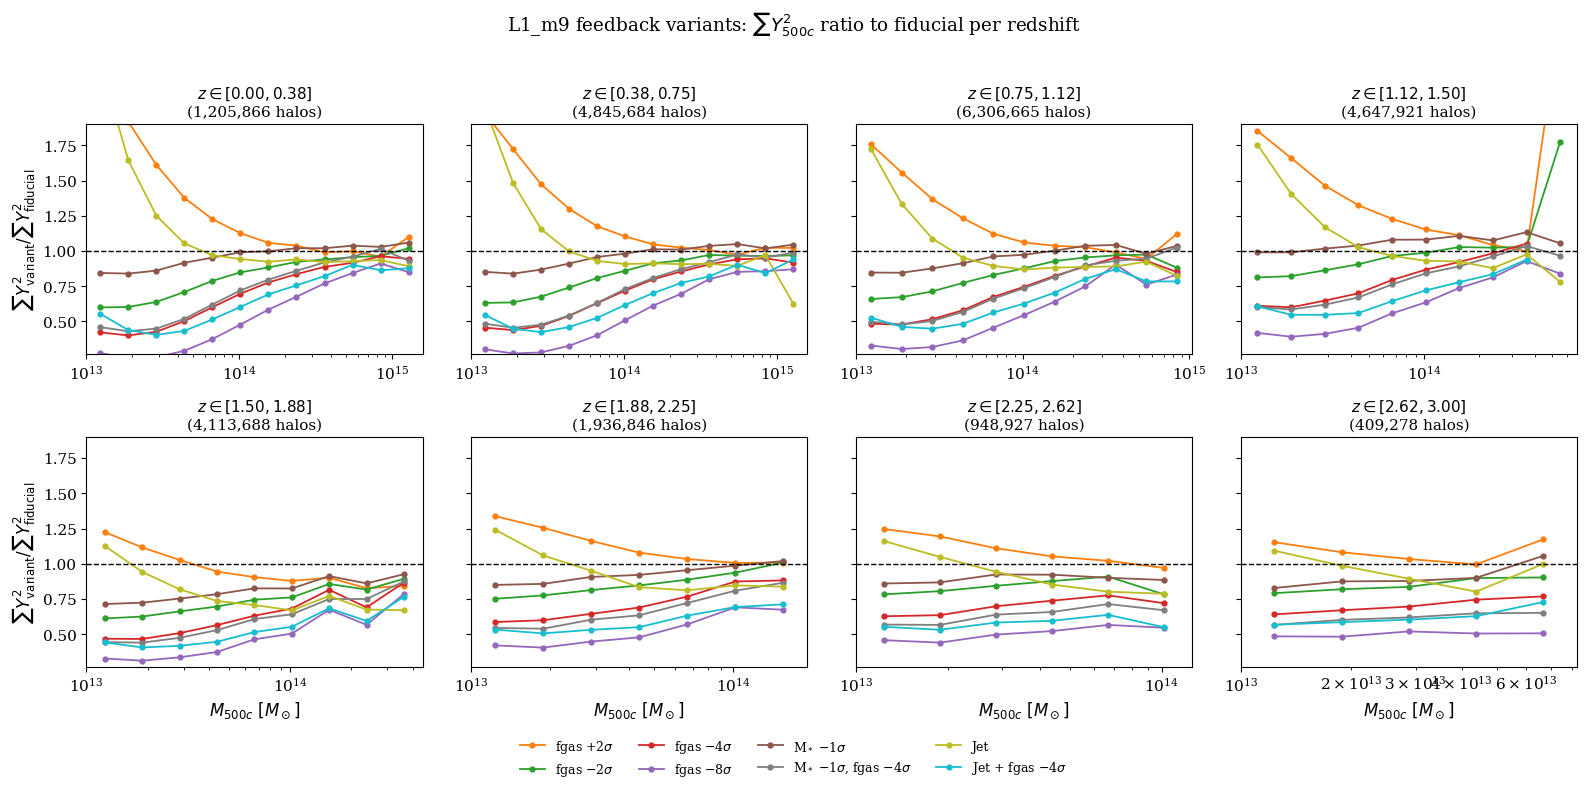

Saved to /scratch/scratch-lxu/flamingo_repo/figures/nb45_compton_y2_ratio_all_variants_Mz


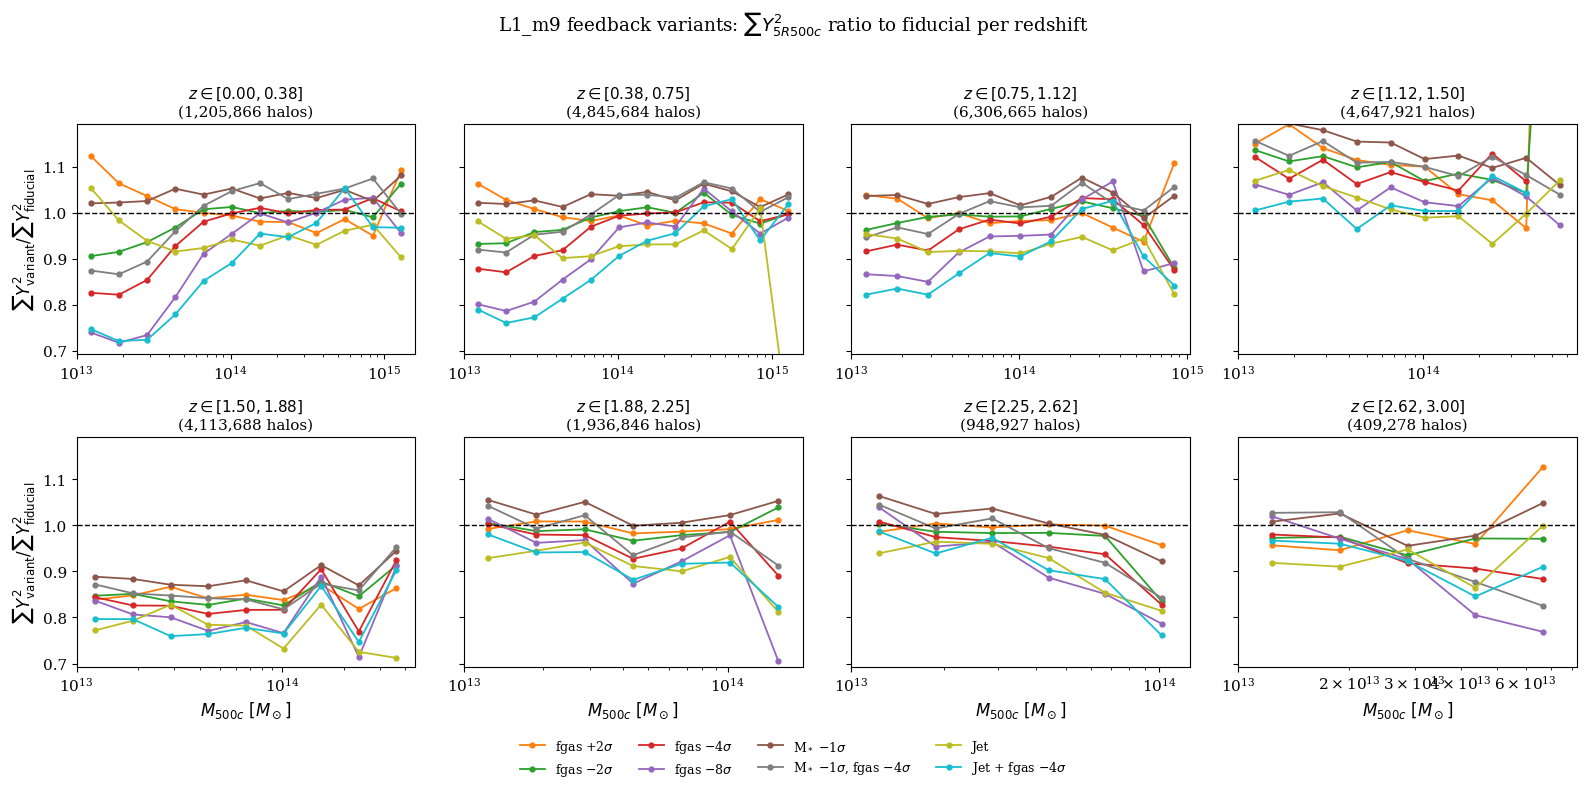

Saved to /scratch/scratch-lxu/flamingo_repo/figures/nb45_compton_y2_ratio_all_variants_Mz


In [6]:
# --- All-variant ratio panels: separate redshift panels, lines = variants ---

def plot_ratio_panels(radius, filename, title):
    # 2 rows x 4 columns: all 8 redshift panels are used, no empty hidden panels
    fig, axes = plt.subplots(2, 4, figsize=(16, 7.5), sharex=False, sharey=True)
    axes = axes.ravel()
    n_z = len(Z_CEN)
    c_fid = C["L1_m9"][radius]

    # Tight y-axis limits from the 1st-99th percentile of the ratios (keeps most of the data)
    vals = np.concatenate([R[radius][v].ravel() for v in VARIANTS[1:]])
    vals = vals[np.isfinite(vals)]
    ylo = max(0.0, np.percentile(vals, 1) - 0.03)
    yhi = np.percentile(vals, 99) + 0.03

    for zi in range(n_z):
        ax = axes[zi]
        for variant in VARIANTS[1:]:
            y = R[radius][variant][:, zi]
            ax.plot(M_CEN, y, "o-", ms=3.5, lw=1.3, color=VARIANT_COLORS[variant],
                    label=LABELS[variant] if zi == 0 else None)
        ax.axhline(1.0, color="k", ls="--", lw=1.0)
        ax.set_xscale("log")
        ax.set_ylim(ylo, yhi)
        # Tight per-panel x limits based on where fiducial has any halos
        populated = np.nonzero(c_fid[:, zi] > 0)[0]
        if populated.size > 0:
            m_low = M_EDGES[populated[0]]
            m_high = M_EDGES[populated[-1] + 1]
            ax.set_xlim(m_low, m_high)
        else:
            ax.set_xlim(M_EDGES[0], M_EDGES[-1])
        ax.set_title(rf"$z \in [{Z_EDGES[zi]:.2f}, {Z_EDGES[zi+1]:.2f}]$" + f"\n({int(c_fid[:, zi].sum()):,} halos)")
        if zi % 4 == 0:
            ax.set_ylabel(r"$\sum Y^2_{\rm variant} / \sum Y^2_{\rm fiducial}$")
        if zi >= n_z - 4:
            ax.set_xlabel(r"$M_{500c}\ [M_\odot]$")

    # Place legend below the bottom row, spanning the full width
    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", ncol=4, fontsize=9, frameon=False,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(title, y=1.02)
    fig.tight_layout(rect=[0.0, 0.05, 1.0, 1.0])
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{filename}.{ext}", bbox_inches="tight")
    plt.show()
    print("Saved to", FIG_DIR)

plot_ratio_panels(
    "Y_500c_Mpc2",
    "sumY2_ratio_allvariants_Y500c_vsM",
    r"L1_m9 feedback variants: $\sum Y_{500c}^2$ ratio to fiducial per redshift",
)

plot_ratio_panels(
    "Y_5R500c_Mpc2",
    "sumY2_ratio_allvariants_Y5R500c_vsM",
    r"L1_m9 feedback variants: $\sum Y_{5R500c}^2$ ratio to fiducial per redshift",
)


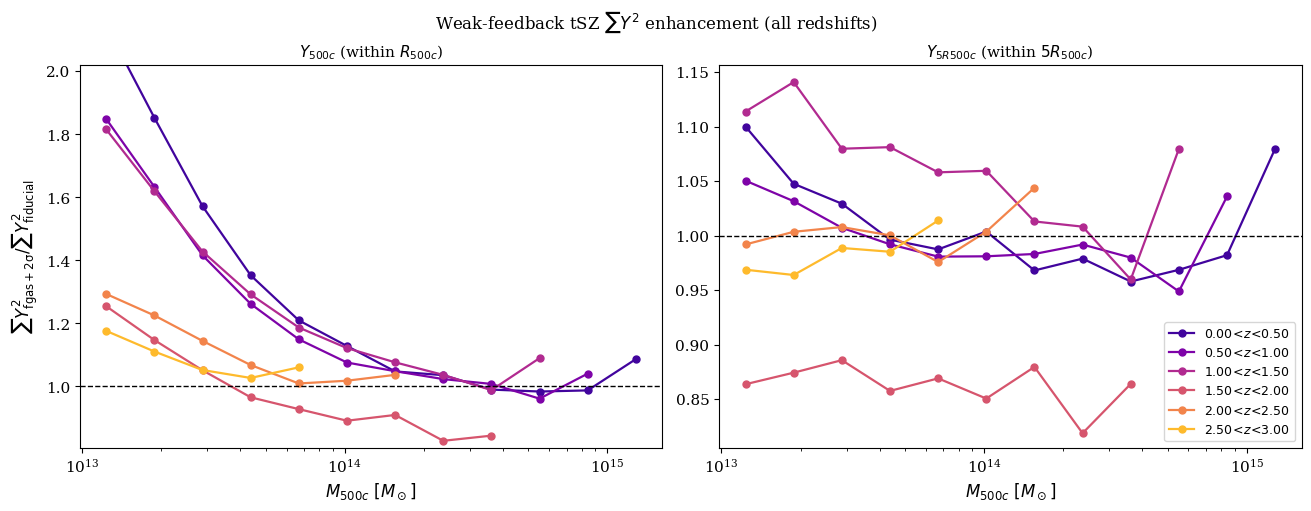

In [7]:
# --- Focused comparison: fgas+2sigma vs fiducial across all redshifts ---
# Re-bin into a coarser 6 redshift bins for the overlap-style plot
ZLO, ZHI = 0.0, 3.0
Z6_EDGES = np.linspace(ZLO, ZHI, 7)
Z6_CEN = 0.5 * (Z6_EDGES[:-1] + Z6_EDGES[1:])
M6_EDGES = np.logspace(13.0, 15.2, 13)
M6_CEN = np.sqrt(M6_EDGES[:-1] * M6_EDGES[1:])

def sumsq_counts_6bin(path, ycol):
    s = np.zeros((len(M6_EDGES) - 1, len(Z6_EDGES) - 1), dtype=np.float64)
    c = np.zeros((len(M6_EDGES) - 1, len(Z6_EDGES) - 1), dtype=np.float64)
    for chunk in pd.read_csv(
        path,
        comment="#",
        usecols=["z", "M_500c_Msun", ycol],
        dtype={"z": np.float64, "M_500c_Msun": np.float64, ycol: np.float64},
        chunksize=2_000_000,
    ):
        m = chunk["M_500c_Msun"].to_numpy()
        z = chunk["z"].to_numpy()
        y = chunk[ycol].to_numpy()
        ok = np.isfinite(m) & np.isfinite(z) & np.isfinite(y) & (z >= ZLO) & (z <= ZHI)
        m, z, y = m[ok], z[ok], y[ok]
        s += np.histogram2d(m, z, bins=[M6_EDGES, Z6_EDGES], weights=y**2)[0]
        c += np.histogram2d(m, z, bins=[M6_EDGES, Z6_EDGES])[0]
    return s, c

ratios_fgas2 = {}
for r in RADII:
    s_fid, c_fid = sumsq_counts_6bin(CAT_DIR / "halo_catalogue_M500c_1e13_zlt3_L1_m9_yang26rot.csv", r)
    s_alt, c_alt = sumsq_counts_6bin(CAT_DIR / "halo_catalogue_M500c_1e13_zlt3_fgas+2sigma_yang26rot.csv", r)
    ok = (c_fid >= MIN_COUNT) & (c_alt >= MIN_COUNT) & (s_fid > 0)
    R6 = np.full_like(s_fid, np.nan)
    R6[ok] = s_alt[ok] / s_fid[ok]
    ratios_fgas2[r] = R6

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0), sharey=False, constrained_layout=True)
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(Z6_CEN)))
for ax, r in zip(axes, RADII):
    for j in range(len(Z6_CEN)):
        ax.plot(M6_CEN, ratios_fgas2[r][:, j], "o-", ms=5, color=colors[j], lw=1.6,
                label=rf"${Z6_EDGES[j]:.2f}\!<\!z\!<\!{Z6_EDGES[j+1]:.2f}$")
    ax.axhline(1.0, color="k", ls="--", lw=1.0)
    ax.set_xscale("log")
    ax.set_xlabel(r"$M_{500c}\ [M_\odot]$")
    ax.set_title(RADIUS_LABELS[r])
    # Tight y-axis per panel from the 1st-99th percentile of the plotted ratios
    vals = ratios_fgas2[r].ravel()
    vals = vals[np.isfinite(vals)]
    ylo = max(0.0, np.percentile(vals, 1) - 0.03)
    yhi = np.percentile(vals, 99) + 0.03
    ax.set_ylim(ylo, yhi)
axes[0].set_ylabel(r"$\sum Y^2_{\rm fgas+2\sigma} / \sum Y^2_{\rm fiducial}$")
axes[1].legend(loc="best")
fig.suptitle(r"Weak-feedback tSZ $\sum Y^2$ enhancement (all redshifts)", fontsize=12)
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"sumY2_ratio_fgas2sigma_vsM_allz.{ext}", dpi=200, bbox_inches="tight")
plt.show()
